<a href="https://colab.research.google.com/github/Kamalashrinithi19/kamalashrinithi-codeboosters-2026/blob/main/Day2/Mini_Project_Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings   # this module manages alerts about code isssues that aren't severe enough to crash the pgm
warnings.filterwarnings('ignore')   # explicitly tells the interpreter "if any warnings come up, just ignore them and don't print them to my screen"

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [4]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:", df.head(3))

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:    student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2                     78      Delh

In [5]:
conn = sqlite3.connect('college.db')
cursor=conn.cursor()  #acts as a pointer or blinking cursor in a text file, allows to navigate and interact with rows of a database and query result one at a time
df.to_sql(
    'students',       #name of the table to create in db
    conn,             #which db connection to use
    if_exists='replace', #if students table already exists replace it
    index=False          #DO NOT write Dataframe row numbers as columns
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print("Database 'college.db' created successfully!")
print(f"Table students has {count} rows")

Database 'college.db' created successfully!
Table students has 30 rows


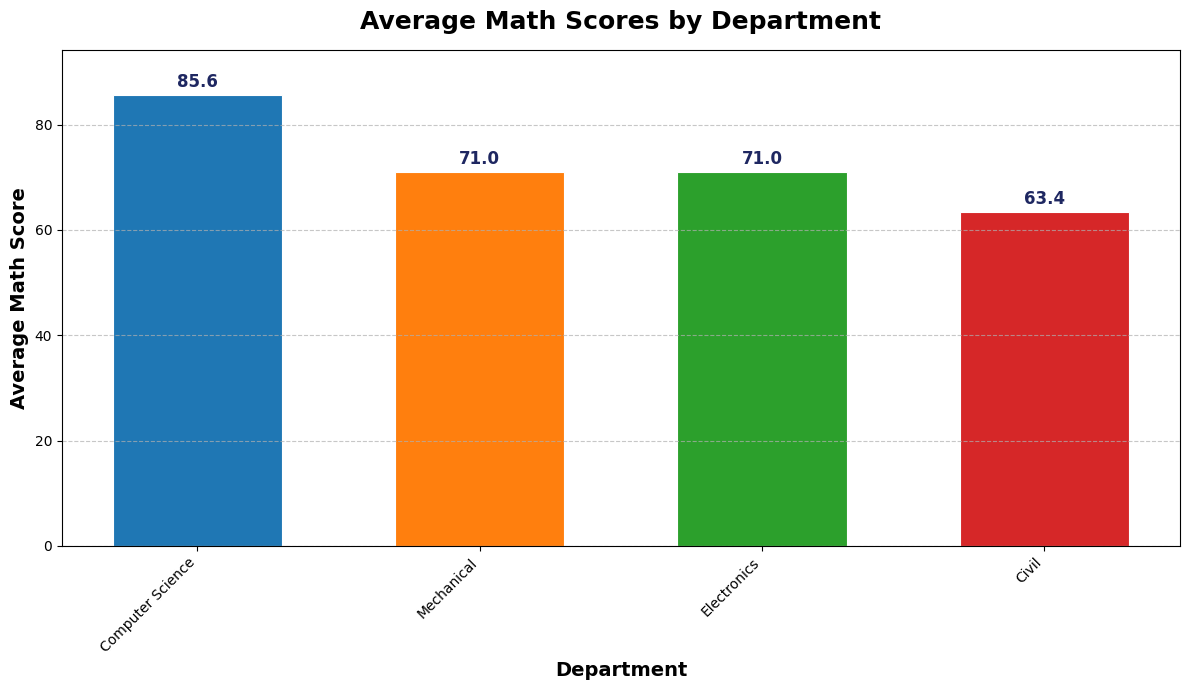

In [6]:
chart1_sql = "SELECT department, ROUND(AVG(math_score), 2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC"
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax= plt.subplots(figsize=(12, 7)) # Increased figure size slightly

# Dynamic color assignment using a different colormap for bright colors
cmap = plt.cm.get_cmap('tab10') # Using 'tab10' colormap for bright and distinct colors
num_departments = len(chart1_data['department'])
colors = [cmap(i) for i in range(num_departments)] # Select colors directly from the colormap

bars=ax.bar(chart1_data['department'], chart1_data['avg_math'], color=colors, edgecolor='white', linewidth=0.8, width=0.6) # Reduced bar width to 0.6

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f}',
      ha='center', va='bottom',
      fontsize=12, fontweight='bold',
      color='#1E2761'
  )

ax.set_title('Average Math Scores by Department', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Math Score', fontsize=14, fontweight='bold')
ax.set_ylim(0, chart1_data['avg_math'].max() * 1.1) # Add some padding above the highest bar
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for readability

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('avg_math_scores_by_department.png', dpi=300) # Save the figure
plt.show()

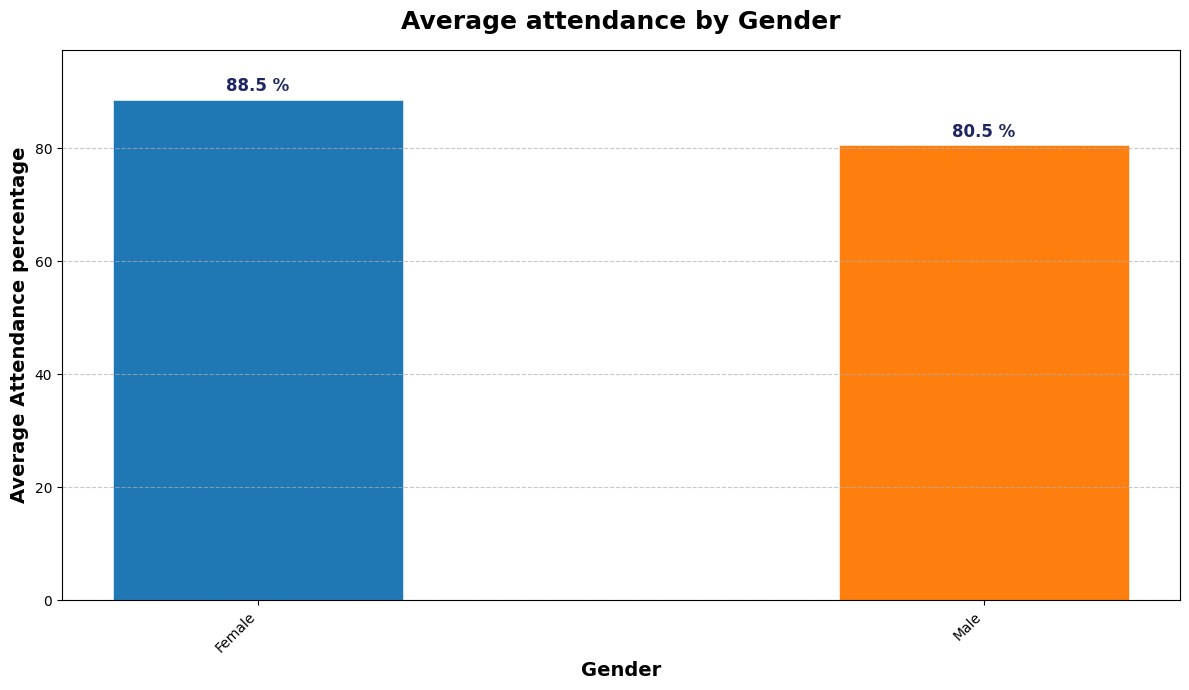

In [16]:
chart1_sql = "SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attendance FROM students GROUP BY gender"
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax= plt.subplots(figsize=(12, 7)) # Increased figure size slightly

# Dynamic color assignment using a different colormap for bright colors
cmap = plt.cm.get_cmap('tab10') # Using 'tab10' colormap for bright and distinct colors
num_departments = len(chart1_data['gender'])
colors = [cmap(i) for i in range(num_departments)] # Select colors directly from the colormap

bars=ax.bar(chart1_data['gender'], chart1_data['avg_attendance'], color=colors, edgecolor='white', linewidth=0.4, width=0.4) # Reduced bar width to 0.6

for bar in bars:
  height=bar.get_height()
  ax.text(
      bar.get_x()+bar.get_width()/2,
      height+0.8,
      f'{height:.1f} %',
      ha='center', va='bottom',
      fontsize=12, fontweight='bold',
      color='#1E2761'
  )

ax.set_title('Average attendance by Gender', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Attendance percentage', fontsize=14, fontweight='bold')
ax.set_ylim(0, chart1_data['avg_attendance'].max() * 1.1) # Add some padding above the highest bar
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for readability

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('avg_attendance_percentage_by_gender.png', dpi=300) # Save the figure
plt.show()

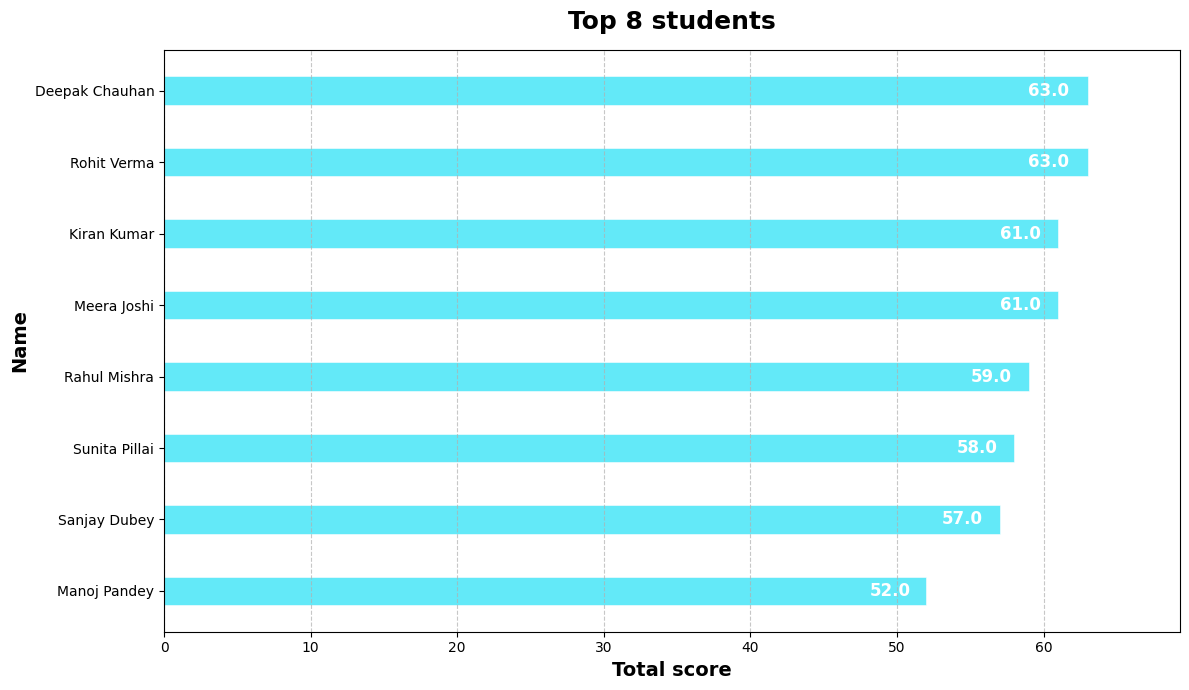

In [35]:
chart1_sql = "SELECT name, (math_score + english_score+ science_score + programming_score)/4 AS total_score FROM students ORDER BY total_score LIMIT(8)"
chart1_data = pd.read_sql_query(chart1_sql, conn)

#2: Create the bar chart
fig, ax= plt.subplots(figsize=(12, 7)) # Increased figure size slightly

# Dynamic color assignment using a different colormap for bright colors
cmap = plt.cm.get_cmap('tab10') # Using 'tab10' colormap for bright and distinct colors
num_students = 8
# colors = [cmap(i) for i in range(8)] # Select colors directly from the colormap

bars=ax.barh(chart1_data['name'], chart1_data['total_score'], color='#63E9F8', edgecolor='white', linewidth=0.4, height=0.4) # Changed to barh, height instead of width

for bar in bars:
  width = bar.get_width()
  ax.text(
      width * 0.98, # Adjusted x position to be near the end of the bar
      bar.get_y() + bar.get_height()/2, # Adjusted y position for horizontal bars
      f'{width:.1f}',
      ha='right', va='center', # Adjusted alignment for horizontal bars
      fontsize=12, fontweight='bold',
      color='white' # Changed text color to white
  )

ax.set_title('Top 8 students', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Name', fontsize=14, fontweight='bold') # Swapped labels
ax.set_xlabel('Total score', fontsize=14, fontweight='bold') # Swapped labels
ax.set_xlim(0, chart1_data['total_score'].max() * 1.1) # Changed to xlim
ax.grid(axis='x', linestyle='--', alpha=0.7) # Changed grid axis to x

plt.yticks(rotation=0, ha='right') # Changed to yticks, no rotation needed for horizontal labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('top8_students.png', dpi=300) # Save the figure
plt.show()

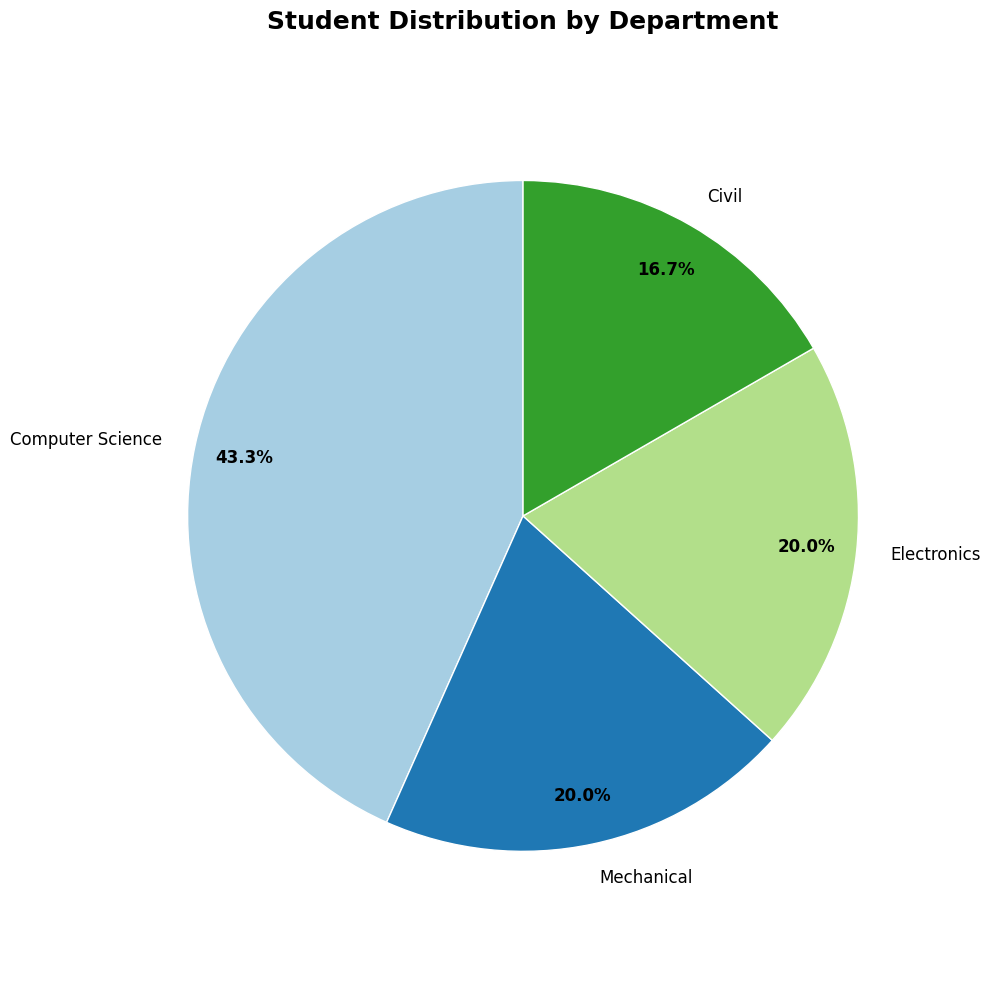

In [38]:
department_sql = "SELECT department, COUNT(student_id) AS student_count FROM students GROUP BY department ORDER BY student_count DESC"
department_data = pd.read_sql_query(department_sql, conn)

fig, ax = plt.subplots(figsize=(10, 10)) # Adjust figure size for better pie chart readability

# Create the pie chart
wedges, texts, autotexts = ax.pie(
    department_data['student_count'],
    labels=department_data['department'],
    autopct='%1.1f%%', # Format for displaying percentages on slices
    startangle=90,     # Start the first slice at the top
    colors=plt.cm.Paired.colors, # Use a colorful colormap
    pctdistance=0.85,   # Distance of percentage labels from the center
    wedgeprops=dict(width=1.0, edgecolor='w') # Changed width to 1.0 for full pie chart
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Style the labels
for text in texts:
    text.set_fontsize(12)

ax.set_title('Student Distribution by Department', fontsize=18, fontweight='bold', pad=20)
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig('student_distribution_by_department.png', dpi=300)
plt.show()